In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


### 2.2 Load Dataset

In [2]:
# Load dataset
df = pd.read_csv('ispu_jakarta_clean.csv')

print('=== INFO DATASET ===')
print(f'Jumlah baris : {df.shape[0]}')
print(f'Jumlah kolom : {df.shape[1]}')
print(f'Nama kolom   : {list(df.columns)}')
print()
df.head(10)

=== INFO DATASET ===
Jumlah baris : 14577
Jumlah kolom : 12
Nama kolom   : ['tanggal', 'periode_data', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori', 'stasiun']



,tanggal,periode_data,pm10,pm25,so2,co,o3,no2,max,critical,categori,stasiun
0,2010-01-01,201001,60.0,NaN,4.0,73.0,27.0,14.0,73.0,CO,SEDANG,DKI1 Bunderan HI
1,2010-01-02,201001,32.0,NaN,2.0,16.0,33.0,9.0,33.0,O3,BAIK,DKI1 Bunderan HI
2,2010-01-03,201001,27.0,NaN,2.0,19.0,20.0,9.0,27.0,PM10,BAIK,DKI1 Bunderan HI
3,2010-01-04,201001,22.0,NaN,2.0,16.0,15.0,6.0,22.0,PM10,BAIK,DKI1 Bunderan HI
4,2010-01-05,201001,25.0,NaN,2.0,17.0,15.0,8.0,25.0,PM10,BAIK,DKI1 Bunderan HI
5,2010-01-06,201001,30.0,NaN,3.0,22.0,19.0,11.0,30.0,PM10,BAIK,DKI1 Bunderan HI
6,2010-01-07,201001,41.0,NaN,4.0,24.0,27.0,13.0,41.0,PM10,BAIK,DKI1 Bunderan HI
7,2010-01-08,201001,64.0,NaN,8.0,51.0,19.0,15.0,64.0,PM10,SEDANG,DKI1 Bunderan HI
8,2010-01-09,201001,55.0,NaN,5.0,39.0,23.0,16.0,55.0,PM10,SEDANG,DKI1 Bunderan HI
9,2010-01-10,201001,34.0,NaN,5.0,23.0,26.0,12.0,34.0,PM10,BAIK,DKI1 Bunderan HI


### 2.3 Data Understanding

In [3]:
# Informasi tipe data
print('=== TIPE DATA ===')
df.info()

=== TIPE DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14577 entries, 0 to 14576
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   tanggal       14577 non-null  object 
 1   periode_data  14577 non-null  int64  
 2   pm10          14577 non-null  float64
 3   pm25          5518 non-null   float64
 4   so2           14574 non-null  float64
 5   co            14577 non-null  float64
 6   o3            14577 non-null  float64
 7   no2           14577 non-null  float64
 8   max           14577 non-null  float64
 9   critical      14577 non-null  object 
 10  categori      14577 non-null  object 
 11  stasiun       14577 non-null  object 
dtypes: float64(7), int64(1), object(4)
memory usage: 1.3+ MB


In [4]:
# Statistik deskriptif
print('=== STATISTIK DESKRIPTIF ===')
df.describe().round(2)

=== STATISTIK DESKRIPTIF ===


,periode_data,pm10,pm25,so2,co,o3,no2,max
count,14577.00,14577.00,5518.00,14574.00,14577.00,14577.00,14577.00,14577.00
mean,201728.26,54.47,74.70,23.61,20.85,60.75,14.29,76.84
std,387.31,18.79,22.72,14.77,13.33,39.16,9.73,33.82
min,201001.00,2.00,13.00,0.00,0.00,3.00,0.00,1.00
25%,201407.00,43.00,57.03,12.00,11.00,32.00,8.00,55.00
50%,201705.00,55.50,72.00,21.00,18.00,54.00,13.00,72.00
75%,202103.00,65.00,88.10,32.00,27.00,79.00,18.00,91.00
max,202311.00,179.00,287.00,112.00,135.00,314.00,135.00,314.00


In [5]:
# Cek missing values
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df[missing_df['Jumlah Missing'] > 0])

=== MISSING VALUES ===
      Jumlah Missing  Persentase (%)
pm25            9059           62.15
so2                3            0.02


In [6]:
# Distribusi kategori kualitas udara
print('=== DISTRIBUSI KATEGORI KUALITAS UDARA ===')
print(df['categori'].value_counts())
print()

print('=== DISTRIBUSI STASIUN ===')
print(df['stasiun'].value_counts())

=== DISTRIBUSI KATEGORI KUALITAS UDARA ===
categori
SEDANG                9733
BAIK                  2398
TIDAK SEHAT           2258
SANGAT TIDAK SEHAT     187
BERBAHAYA                1
Name: count, dtype: int64

=== DISTRIBUSI STASIUN ===
stasiun
DKI4 Lubang Buaya     3345
DKI1 Bunderan HI      2940
DKI3 Jagakarsa        2930
DKI2 Kelapa Gading    2881
DKI5 Kebon Jeruk      2481
Name: count, dtype: int64


### 2.4 Visualisasi Data Awal

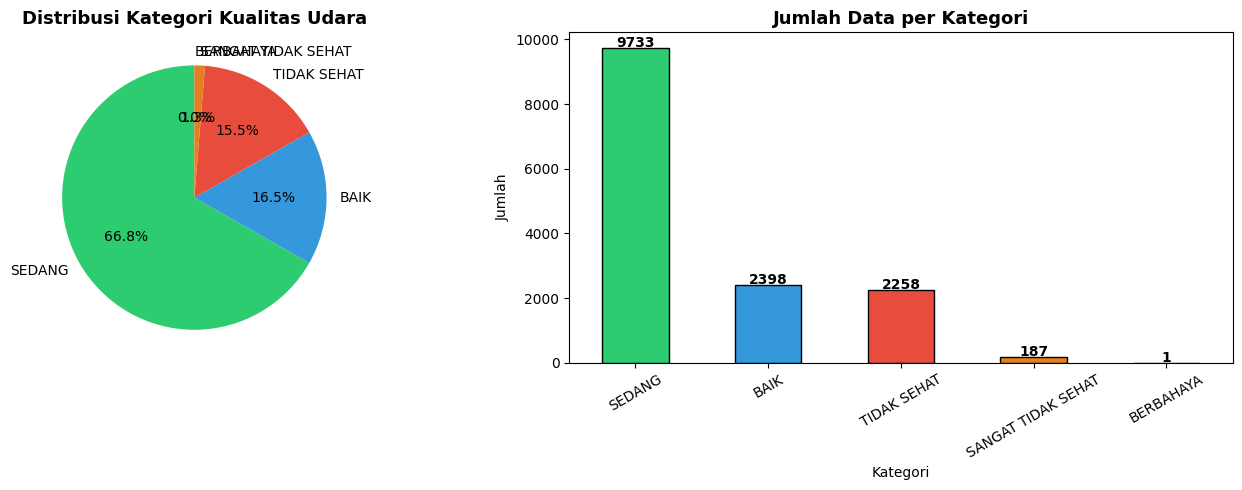

Visualisasi 1 berhasil disimpan.


In [7]:
# Visualisasi 1: Distribusi Kategori Kualitas Udara
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
kategori_counts = df['categori'].value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#e67e22', '#9b59b6']
axes[0].pie(kategori_counts.values, labels=kategori_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Distribusi Kategori Kualitas Udara', fontsize=13, fontweight='bold')

# Bar chart
kategori_counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Jumlah Data per Kategori', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(kategori_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_1_kategori.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 1 berhasil disimpan.')

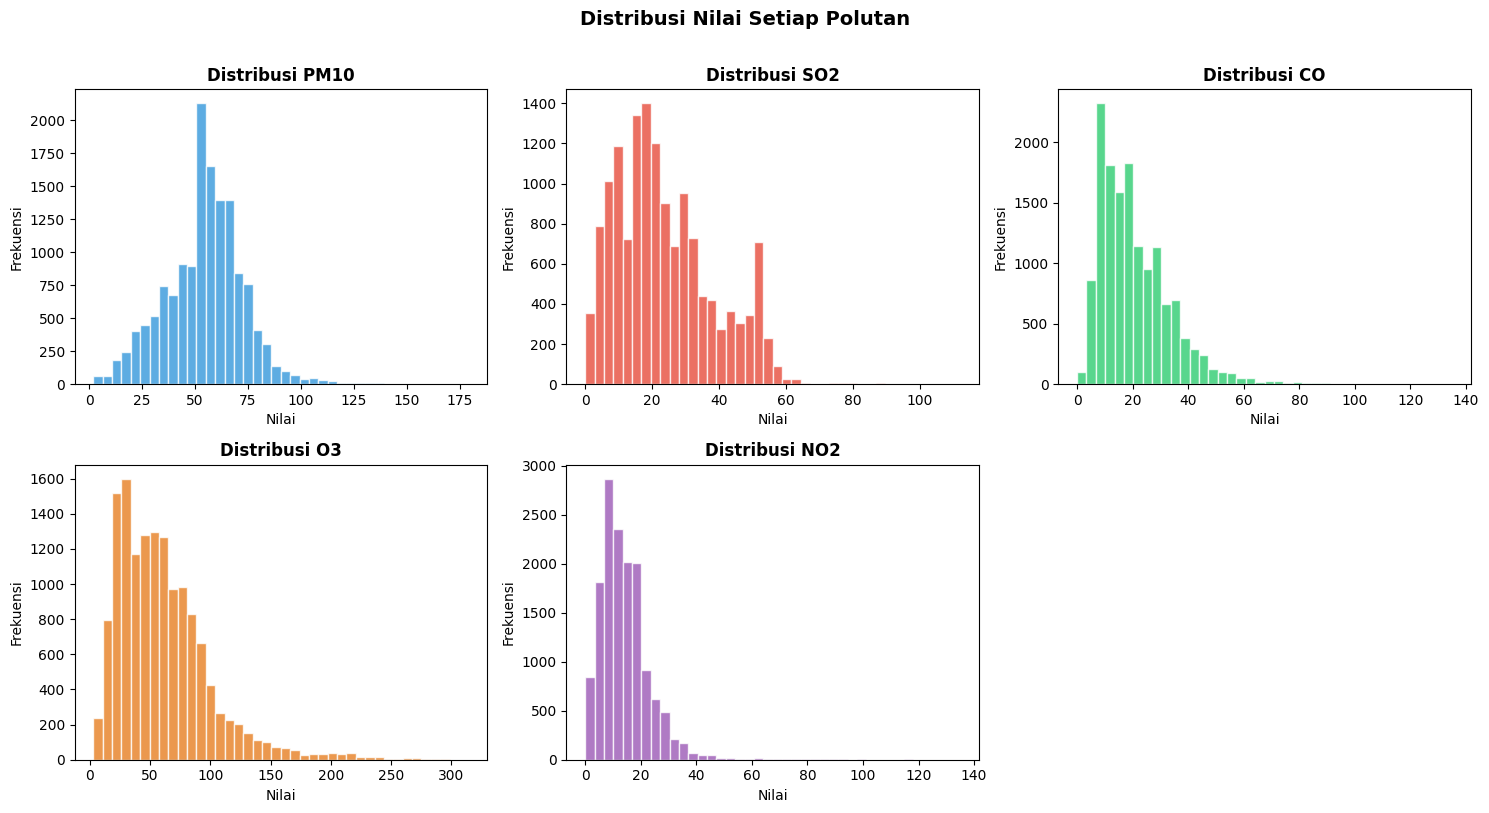

Visualisasi 2 berhasil disimpan.


In [8]:
# Visualisasi 2: Distribusi nilai polutan
fitur_polutan = ['pm10', 'so2', 'co', 'o3', 'no2']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors_hist = ['#3498db', '#e74c3c', '#2ecc71', '#e67e22', '#9b59b6']
for i, col in enumerate(fitur_polutan):
    axes[i].hist(df[col].dropna(), bins=40, color=colors_hist[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi {col.upper()}', fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

axes[5].axis('off')
plt.suptitle('Distribusi Nilai Setiap Polutan', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_2_distribusi_polutan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 2 berhasil disimpan.')

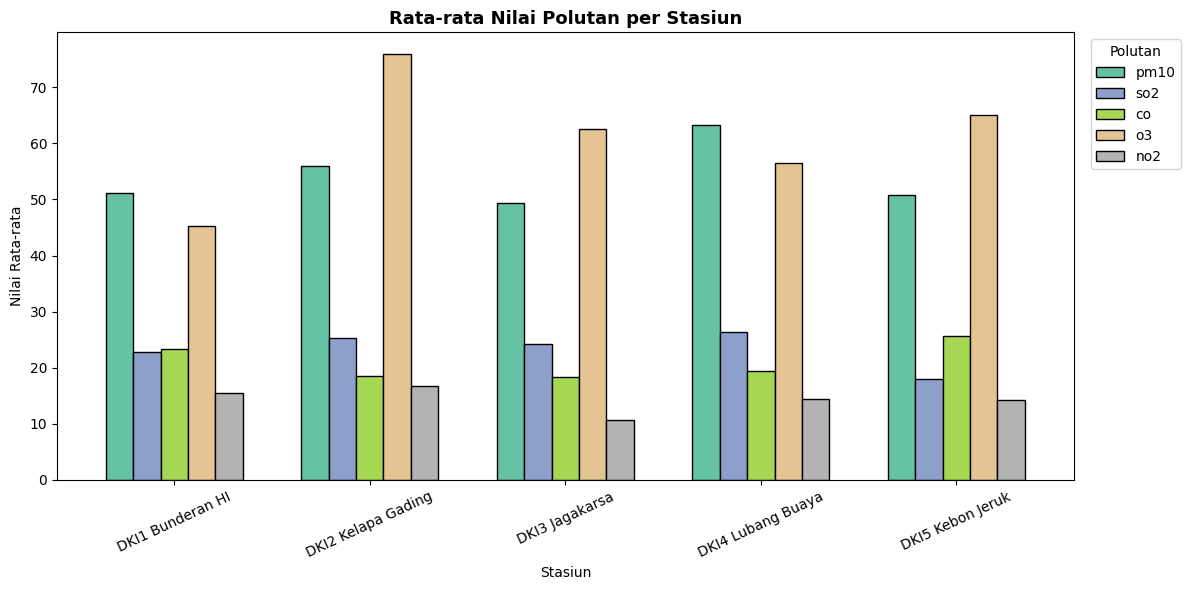

Visualisasi 3 berhasil disimpan.


In [9]:
# Visualisasi 3: Rata-rata polutan per stasiun
stasiun_avg = df.groupby('stasiun')[fitur_polutan].mean().round(2)

fig, ax = plt.subplots(figsize=(12, 6))
stasiun_avg.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', width=0.7)
ax.set_title('Rata-rata Nilai Polutan per Stasiun', fontsize=13, fontweight='bold')
ax.set_xlabel('Stasiun')
ax.set_ylabel('Nilai Rata-rata')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Polutan', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('viz_3_rata_stasiun.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 3 berhasil disimpan.')

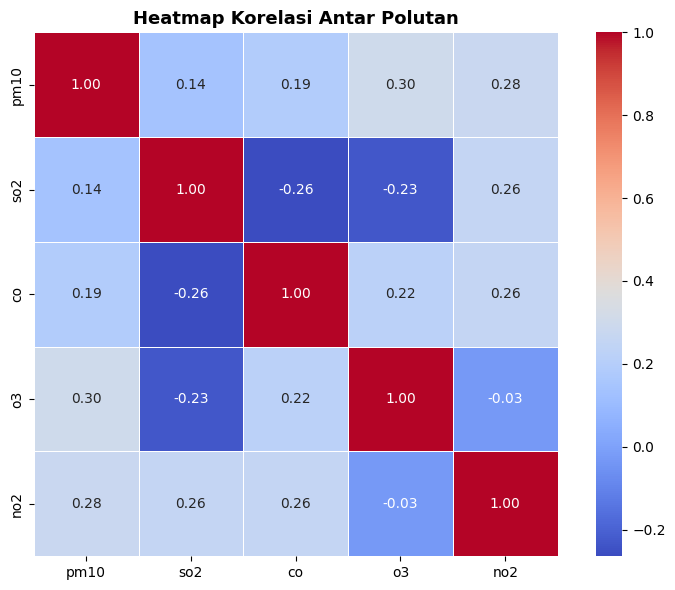

Visualisasi 4 berhasil disimpan.


In [10]:
# Visualisasi 4: Heatmap korelasi
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df[fitur_polutan].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Heatmap Korelasi Antar Polutan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 4 berhasil disimpan.')

### 2.5 Data Preprocessing

In [11]:
# Langkah 1: Pilih fitur numerik untuk clustering
# pm25 dihapus karena terlalu banyak missing value (>60%)
fitur_clustering = ['pm10', 'so2', 'co', 'o3', 'no2', 'max']
df_cluster = df[fitur_clustering].copy()

print('Fitur yang digunakan untuk clustering:')
print(fitur_clustering)
print(f'\nShape data sebelum preprocessing: {df_cluster.shape}')

Fitur yang digunakan untuk clustering:
['pm10', 'so2', 'co', 'o3', 'no2', 'max']

Shape data sebelum preprocessing: (14577, 6)


In [12]:
# Langkah 2: Tangani missing values dengan median (robust terhadap outlier)
for col in fitur_clustering:
    median_val = df_cluster[col].median()
    missing_count = df_cluster[col].isnull().sum()
    df_cluster[col] = df_cluster[col].fillna(median_val)
    if missing_count > 0:
        print(f'Kolom {col}: {missing_count} missing values diisi dengan median = {median_val:.2f}')

print(f'\nTotal missing values setelah preprocessing: {df_cluster.isnull().sum().sum()}')
print(f'Shape data setelah preprocessing: {df_cluster.shape}')

Kolom so2: 3 missing values diisi dengan median = 21.00

Total missing values setelah preprocessing: 0
Shape data setelah preprocessing: (14577, 6)


In [13]:
# Langkah 3: Normalisasi fitur dengan StandardScaler
# Penting untuk K-Means agar tidak ada fitur yang mendominasi karena skala berbeda
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=fitur_clustering)

print('=== DATA SETELAH NORMALISASI (5 baris pertama) ===')
print(X_scaled_df.head())
print()
print('=== STATISTIK SETELAH NORMALISASI ===')
print(X_scaled_df.describe().round(4))

=== DATA SETELAH NORMALISASI (5 baris pertama) ===
       pm10       so2        co        o3       no2       max
0  0.294238 -1.328338  3.914056 -0.862040 -0.030142 -0.113620
1 -1.195828 -1.463803 -0.363664 -0.708805 -0.544019 -1.296287
2 -1.461911 -1.463803 -0.138521 -1.040814 -0.544019 -1.473687
3 -1.727995 -1.463803 -0.363664 -1.168510 -0.852345 -1.621520
4 -1.568345 -1.463803 -0.288616 -1.168510 -0.646794 -1.532820

=== STATISTIK SETELAH NORMALISASI ===
             pm10         so2          co          o3         no2         max
count  14577.0000  14577.0000  14577.0000  14577.0000  14577.0000  14577.0000
mean       0.0000      0.0000      0.0000     -0.0000      0.0000      0.0000
std        1.0000      1.0000      1.0000      1.0000      1.0000      1.0000
min       -2.7923     -1.5993     -1.5644     -1.4750     -1.4690     -2.2424
25%       -0.6104     -0.7865     -0.7389     -0.7343     -0.6468     -0.6458
50%        0.0548     -0.1769     -0.2136     -0.1725     -0.1329     

### 2.6 Implementasi K-Means Clustering

In [14]:
# Langkah 1: Tentukan jumlah cluster optimal dengan Elbow Method
inertia_list = []
silhouette_list = []
K_range = range(2, 11)

print('Menghitung nilai Inertia dan Silhouette Score untuk setiap K...')
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia_list.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_list.append(sil_score)
    print(f'  K={k} | Inertia: {kmeans.inertia_:.2f} | Silhouette: {sil_score:.4f}')

Menghitung nilai Inertia dan Silhouette Score untuk setiap K...
  K=2 | Inertia: 68579.18 | Silhouette: 0.2536
  K=3 | Inertia: 55715.59 | Silhouette: 0.2485
  K=4 | Inertia: 48400.99 | Silhouette: 0.2328
  K=5 | Inertia: 43237.85 | Silhouette: 0.2106
  K=6 | Inertia: 38984.29 | Silhouette: 0.2175
  K=7 | Inertia: 36068.93 | Silhouette: 0.2092
  K=8 | Inertia: 33342.63 | Silhouette: 0.2037
  K=9 | Inertia: 31366.02 | Silhouette: 0.2001
  K=10 | Inertia: 29864.47 | Silhouette: 0.1970


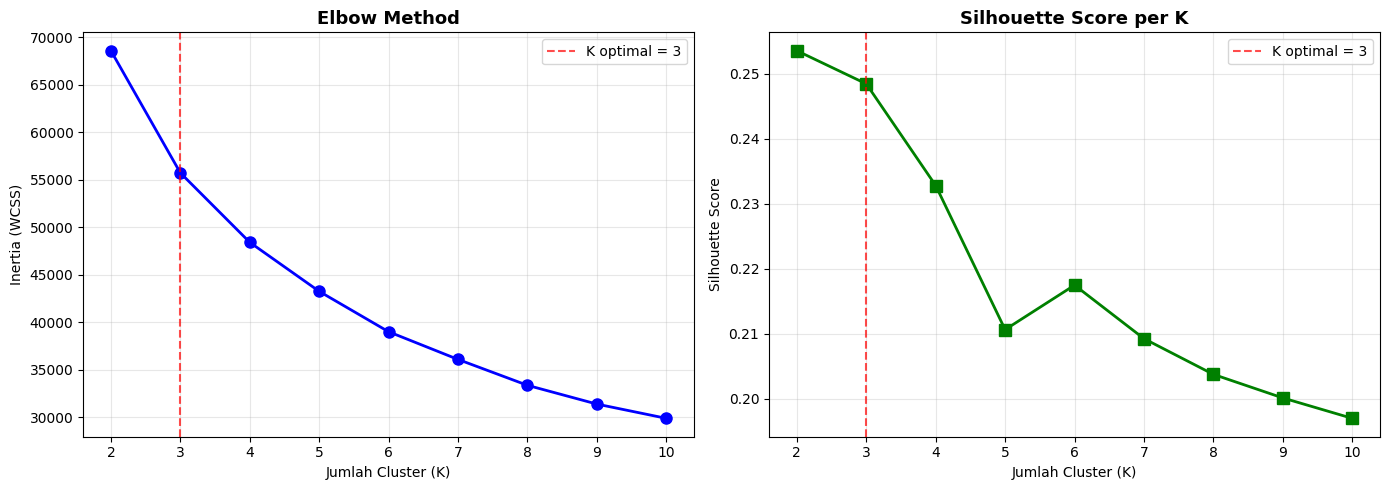

Visualisasi Elbow Method berhasil disimpan.


In [15]:
# Visualisasi Elbow Method
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(K_range), inertia_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K optimal = 3')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(list(K_range), silhouette_list, 'rs-', linewidth=2, markersize=8, color='green')
axes[1].set_title('Silhouette Score per K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K optimal = 3')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viz_5_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi Elbow Method berhasil disimpan.')

In [16]:
# Langkah 2: Training K-Means dengan K=3 (optimal)
K_OPTIMAL = 3

kmeans_final = KMeans(
    n_clusters=K_OPTIMAL,
    init='k-means++',      # Inisialisasi cerdas untuk hasil lebih baik
    n_init=10,             # Jalankan 10 kali dengan centroid berbeda
    max_iter=300,          # Maksimum iterasi
    random_state=42        # Reproducibility
)

kmeans_final.fit(X_scaled)
cluster_labels = kmeans_final.labels_

# Tambahkan label cluster ke dataframe asli
df['cluster'] = cluster_labels
df_cluster['cluster'] = cluster_labels

print(f'K-Means berhasil dijalankan dengan K={K_OPTIMAL}')
print(f'\nJumlah data per cluster:')
for c in range(K_OPTIMAL):
    count = (cluster_labels == c).sum()
    print(f'  Cluster {c}: {count} data ({count/len(cluster_labels)*100:.1f}%)')

K-Means berhasil dijalankan dengan K=3

Jumlah data per cluster:
  Cluster 0: 3754 data (25.8%)
  Cluster 1: 7313 data (50.2%)
  Cluster 2: 3510 data (24.1%)


### 2.7 Hasil Analisis / Testing (Evaluasi)

In [17]:
# Evaluasi model
sil_final = silhouette_score(X_scaled, cluster_labels)
db_final = davies_bouldin_score(X_scaled, cluster_labels)
inertia_final = kmeans_final.inertia_

print('=== EVALUASI MODEL K-MEANS (K=3) ===')
print(f'Inertia (WCSS)       : {inertia_final:.4f}')
print(f'Silhouette Score     : {sil_final:.4f}  (semakin mendekati 1 = semakin baik)')
print(f'Davies-Bouldin Score : {db_final:.4f}  (semakin kecil = semakin baik)')
print()
if sil_final > 0.5:
    print('=> Silhouette Score > 0.5: Struktur cluster KUAT')
elif sil_final > 0.25:
    print('=> Silhouette Score 0.25-0.5: Struktur cluster CUKUP')
else:
    print('=> Silhouette Score < 0.25: Struktur cluster LEMAH')

=== EVALUASI MODEL K-MEANS (K=3) ===
Inertia (WCSS)       : 55715.5918
Silhouette Score     : 0.2485  (semakin mendekati 1 = semakin baik)
Davies-Bouldin Score : 1.3758  (semakin kecil = semakin baik)

=> Silhouette Score < 0.25: Struktur cluster LEMAH


In [18]:
# Karakteristik setiap cluster (rata-rata nilai polutan)
cluster_profile = df.groupby('cluster')[fitur_clustering].mean().round(2)
print('=== PROFIL RATA-RATA SETIAP CLUSTER ===')
print(cluster_profile)
print()

# Komposisi kategori per cluster
print('=== KOMPOSISI KATEGORI KUALITAS UDARA PER CLUSTER ===')
cross_tab = pd.crosstab(df['cluster'], df['categori'])
print(cross_tab)

=== PROFIL RATA-RATA SETIAP CLUSTER ===
          pm10    so2     co      o3    no2     max
cluster                                            
0        59.18  41.62  15.05   37.56  21.69   80.30
1        44.82  16.72  19.44   49.62   9.82   57.78
2        69.54  18.71  29.97  108.76  15.71  112.86

=== KOMPOSISI KATEGORI KUALITAS UDARA PER CLUSTER ===
categori  BAIK  BERBAHAYA  SANGAT TIDAK SEHAT  SEDANG  TIDAK SEHAT
cluster                                                           
0           80          0                   0    3058          616
1         2316          0                   0    4942           55
2            2          1                 187    1733         1587


In [19]:
# Beri label nama cluster berdasarkan profil polutan
cluster_means = df.groupby('cluster')['max'].mean()
sorted_clusters = cluster_means.sort_values().index.tolist()

label_map = {
    sorted_clusters[0]: 'Cluster 0: Polusi Rendah',
    sorted_clusters[1]: 'Cluster 1: Polusi Sedang',
    sorted_clusters[2]: 'Cluster 2: Polusi Tinggi'
}
df['cluster_label'] = df['cluster'].map(label_map)

print('=== RATA-RATA MAX ISPU PER CLUSTER ===')
for k, v in label_map.items():
    avg = df[df['cluster'] == k]['max'].mean()
    print(f'  {v}: rata-rata MAX = {avg:.2f}')

=== RATA-RATA MAX ISPU PER CLUSTER ===
  Cluster 0: Polusi Rendah: rata-rata MAX = 57.78
  Cluster 1: Polusi Sedang: rata-rata MAX = 80.30
  Cluster 2: Polusi Tinggi: rata-rata MAX = 112.86


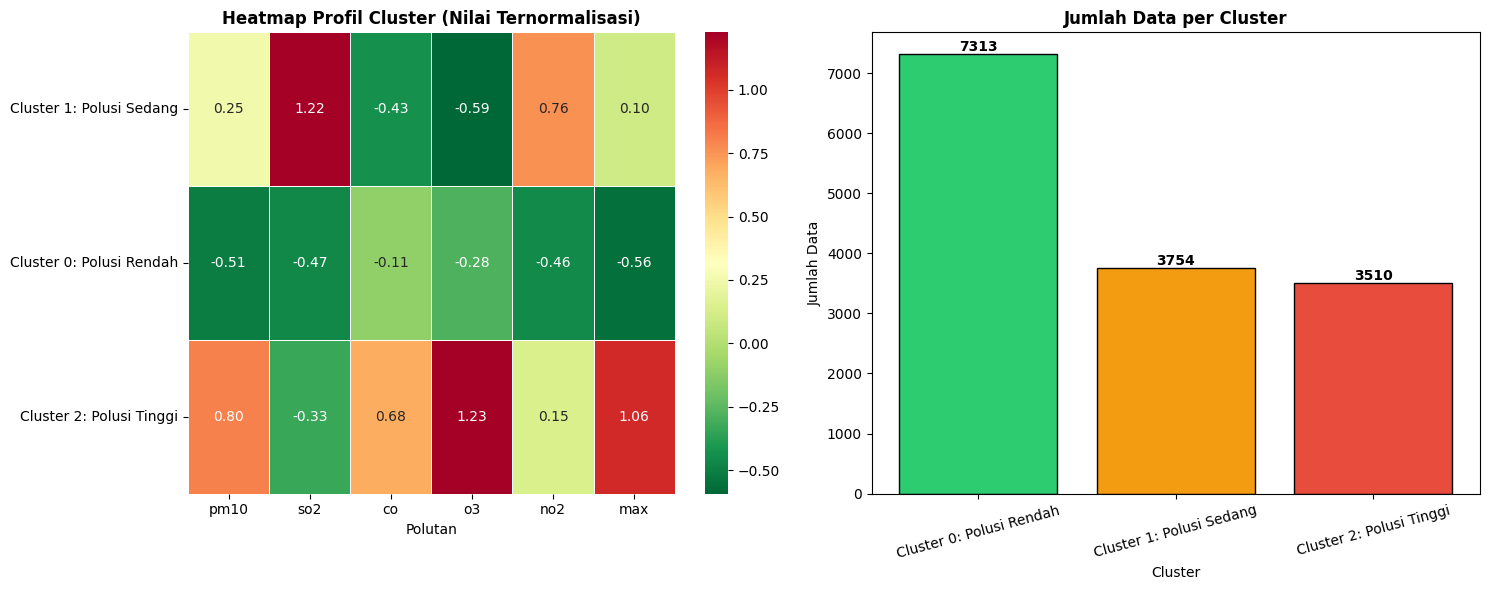

Visualisasi profil cluster berhasil disimpan.


In [20]:
# Visualisasi 6: Profil rata-rata polutan per cluster (radar/bar)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap profil cluster
cluster_scaled_profile = pd.DataFrame(
    scaler.transform(cluster_profile[fitur_clustering]),
    columns=fitur_clustering,
    index=[label_map[i] for i in cluster_profile.index]
)
sns.heatmap(cluster_scaled_profile, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Heatmap Profil Cluster (Nilai Ternormalisasi)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Polutan')

# Bar chart distribusi cluster
cluster_count = df['cluster_label'].value_counts()
bars = axes[1].bar(cluster_count.index, cluster_count.values,
                   color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
axes[1].set_title('Jumlah Data per Cluster', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Jumlah Data')
axes[1].tick_params(axis='x', rotation=15)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 50, f'{int(h)}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_6_profil_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi profil cluster berhasil disimpan.')

Variansi yang dijelaskan PCA: PC1=37.0%, PC2=23.6%
Total variansi: 60.6%


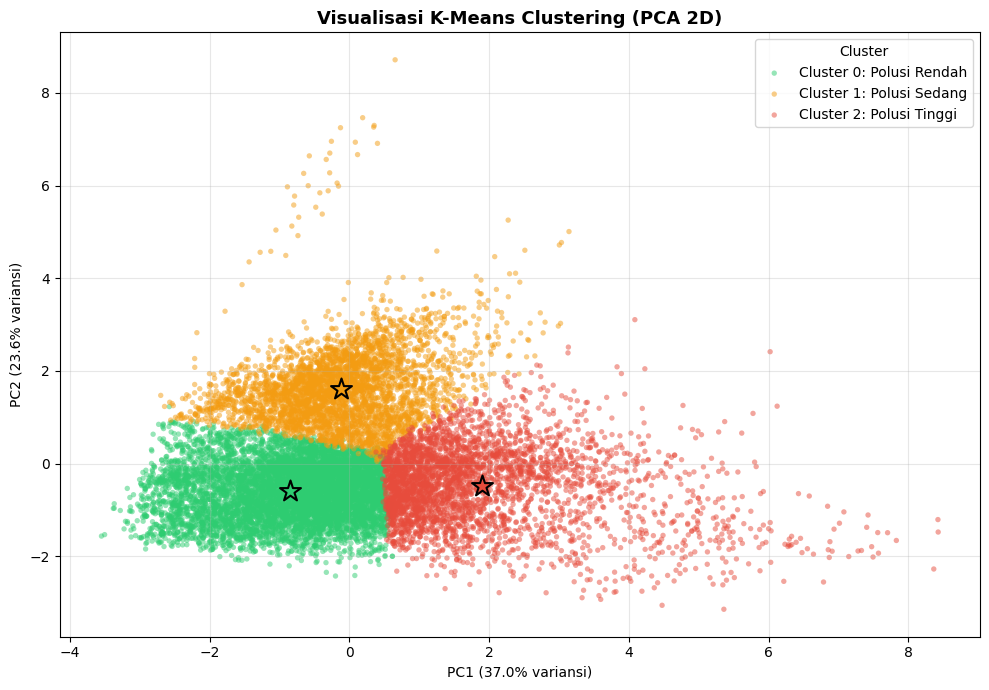

Visualisasi PCA cluster berhasil disimpan.


In [21]:
# Visualisasi 7: PCA 2D untuk menampilkan cluster
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print(f'Variansi yang dijelaskan PCA: PC1={explained_var[0]*100:.1f}%, PC2={explained_var[1]*100:.1f}%')
print(f'Total variansi: {sum(explained_var)*100:.1f}%')

fig, ax = plt.subplots(figsize=(10, 7))
colors_pca = ['#2ecc71', '#f39c12', '#e74c3c']
cluster_order = sorted_clusters

for idx, c in enumerate(cluster_order):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors_pca[idx], label=label_map[c],
               alpha=0.5, s=15, edgecolors='none')

# Plot centroid
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
for idx, c in enumerate(cluster_order):
    ax.scatter(centroids_pca[c, 0], centroids_pca[c, 1],
               c=colors_pca[idx], s=250, marker='*',
               edgecolors='black', linewidths=1.5, zorder=5)

ax.set_title('Visualisasi K-Means Clustering (PCA 2D)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variansi)')
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variansi)')
ax.legend(title='Cluster', loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('viz_7_pca_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi PCA cluster berhasil disimpan.')

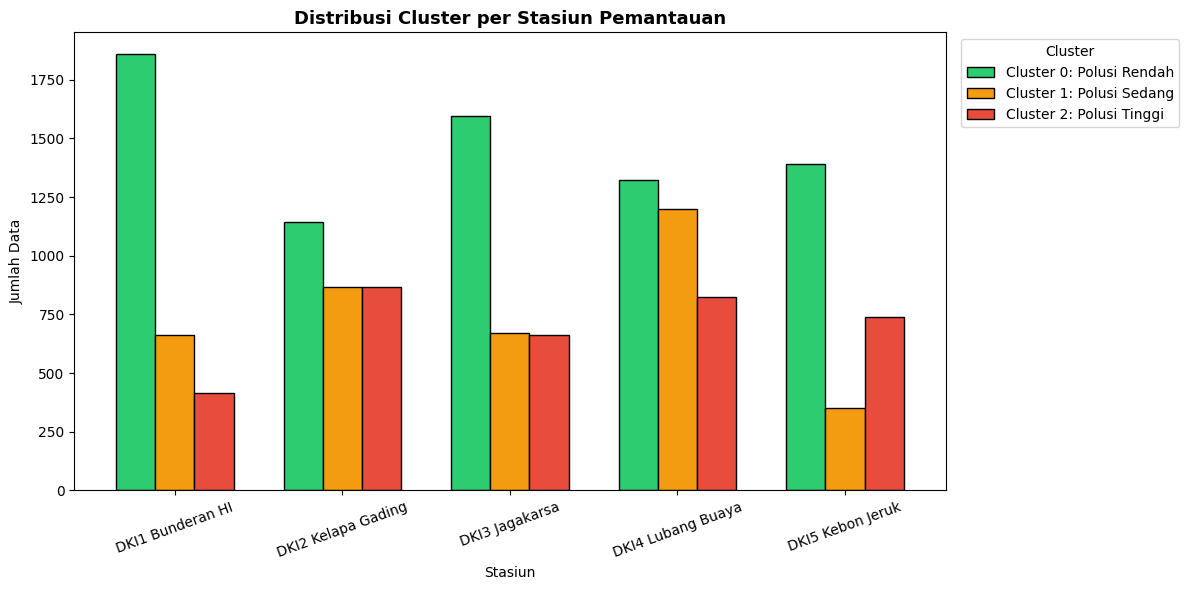

Visualisasi distribusi cluster per stasiun berhasil disimpan.


In [22]:
# Visualisasi 8: Distribusi cluster per stasiun
fig, ax = plt.subplots(figsize=(12, 6))
cross_stasiun = pd.crosstab(df['stasiun'], df['cluster_label'])
cross_stasiun.plot(kind='bar', ax=ax,
                   color=['#2ecc71', '#f39c12', '#e74c3c'],
                   edgecolor='black', width=0.7)
ax.set_title('Distribusi Cluster per Stasiun Pemantauan', fontsize=13, fontweight='bold')
ax.set_xlabel('Stasiun')
ax.set_ylabel('Jumlah Data')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('viz_8_cluster_stasiun.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi distribusi cluster per stasiun berhasil disimpan.')

### 2.8 Insight Hasil Analisis

In [23]:
# Ringkasan insight
print('=' * 65)
print('         INSIGHT HASIL K-MEANS CLUSTERING ISPU JAKARTA')
print('=' * 65)

print()
print('--- PROFIL CLUSTER ---')
print(cluster_profile.to_string())

print()
print('INSIGHT 1: Dominasi Kondisi Polusi Sedang')
print('-' * 50)
c_sedang = sorted_clusters[1]
n_sedang = (cluster_labels == c_sedang).sum()
print(f'Cluster Polusi Sedang memiliki {n_sedang} data ({n_sedang/len(cluster_labels)*100:.1f}%).')
print('Artinya mayoritas hari di Jakarta berada dalam kondisi')
print('kualitas udara SEDANG, bukan baik maupun berbahaya.')
print('Rekomendasi: Perlu kebijakan preventif berkelanjutan')
print('untuk mencegah kualitas udara memburuk lebih lanjut.')

print()
print('INSIGHT 2: CO sebagai Polutan Dominan pada Cluster Tinggi')
print('-' * 50)
c_tinggi = sorted_clusters[2]
co_tinggi = cluster_profile.loc[c_tinggi, 'co']
co_rendah = cluster_profile.loc[sorted_clusters[0], 'co']
print(f'Rata-rata CO pada Cluster Polusi Tinggi: {co_tinggi:.2f}')
print(f'Rata-rata CO pada Cluster Polusi Rendah: {co_rendah:.2f}')
print(f'Selisih: {co_tinggi - co_rendah:.2f} ({(co_tinggi/co_rendah - 1)*100:.1f}% lebih tinggi)')
print('Rekomendasi: Fokus pengendalian emisi CO dari kendaraan')
print('bermotor, terutama di daerah dengan kepadatan lalu lintas tinggi.')

print()
print('INSIGHT 3: Variasi Kualitas Udara Antar Stasiun')
print('-' * 50)
stasiun_cluster = df.groupby('stasiun')['cluster_label'].apply(
    lambda x: x.value_counts().idxmax())
for st, cl in stasiun_cluster.items():
    print(f'  {st}: dominan {cl}')
print('Rekomendasi: Alokasikan sumber daya pengendalian polusi')
print('secara proporsional berdasarkan tingkat polusi tiap stasiun.')

print()
print('=' * 65)

         INSIGHT HASIL K-MEANS CLUSTERING ISPU JAKARTA

--- PROFIL CLUSTER ---
          pm10    so2     co      o3    no2     max
cluster                                            
0        59.18  41.62  15.05   37.56  21.69   80.30
1        44.82  16.72  19.44   49.62   9.82   57.78
2        69.54  18.71  29.97  108.76  15.71  112.86

INSIGHT 1: Dominasi Kondisi Polusi Sedang
--------------------------------------------------
Cluster Polusi Sedang memiliki 3754 data (25.8%).
Artinya mayoritas hari di Jakarta berada dalam kondisi
kualitas udara SEDANG, bukan baik maupun berbahaya.
Rekomendasi: Perlu kebijakan preventif berkelanjutan
untuk mencegah kualitas udara memburuk lebih lanjut.

INSIGHT 2: CO sebagai Polutan Dominan pada Cluster Tinggi
--------------------------------------------------
Rata-rata CO pada Cluster Polusi Tinggi: 29.97
Rata-rata CO pada Cluster Polusi Rendah: 19.44
Selisih: 10.53 (54.2% lebih tinggi)
Rekomendasi: Fokus pengendalian emisi CO dari kendaraan
bermotor